In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4844,ham,Missing you too.pray inshah allah,NaN,NaN,NaN
2472,spam,Final Chance! Claim ur å£150 worth of discount...,NaN,NaN,NaN
2494,ham,You at mu? You should try to figure out how mu...,NaN,NaN,NaN
991,ham,Hi im having the most relaxing time ever! we h...,NaN,NaN,NaN
1132,ham,Good morning princess! How are you?,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
## 1. Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [8]:
df.rename(columns={'v1': 'target', 'v2': 'sms'}, inplace = True)

In [9]:
df.sample(5)

,target,sms
2497,ham,Dai what this da.. Can i send my resume to thi...
826,ham,Hahaha..use your brain dear
2314,ham,Also that chat was awesome but don't make it r...
5212,ham,K.k.how is your business now?
2428,ham,She.s find. I sent you an offline message to k...


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.isnull().sum()

target    0
sms       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df = df.drop_duplicates(keep='first')

In [15]:
df.shape

(5169, 2)

In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

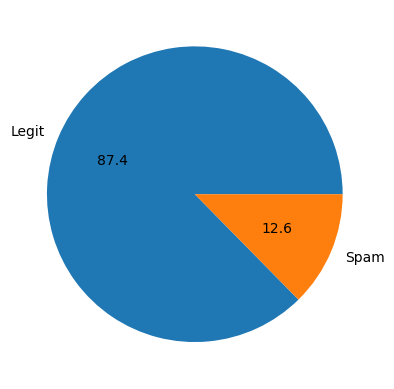

In [17]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ['Legit', 'Spam'], autopct = "%0.1f")
plt.show()

# Now I'll add 3 columns : 1. no. of characters, 2. no. of words, 3. number of sentences

In [18]:
! pip install nltk
import nltk

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANJALI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
df['no_of_char'] = df['sms'].apply(len)

In [21]:
df.head()

,target,sms,no_of_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
df['no_of_words'] = df['sms'].apply(lambda x : len(nltk.word_tokenize(x)))

In [23]:
df['no_of_sentences'] = df['sms'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [24]:
df.head()

,target,sms,no_of_char,no_of_words,no_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['no_of_char', 'no_of_words', 'no_of_sentences']].describe()

,no_of_char,no_of_words,no_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
df[df['target'] == 0][['no_of_char', 'no_of_words', 'no_of_sentences']].describe()

,no_of_char,no_of_words,no_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
import seaborn as sns

<Axes: xlabel='no_of_char', ylabel='Count'>

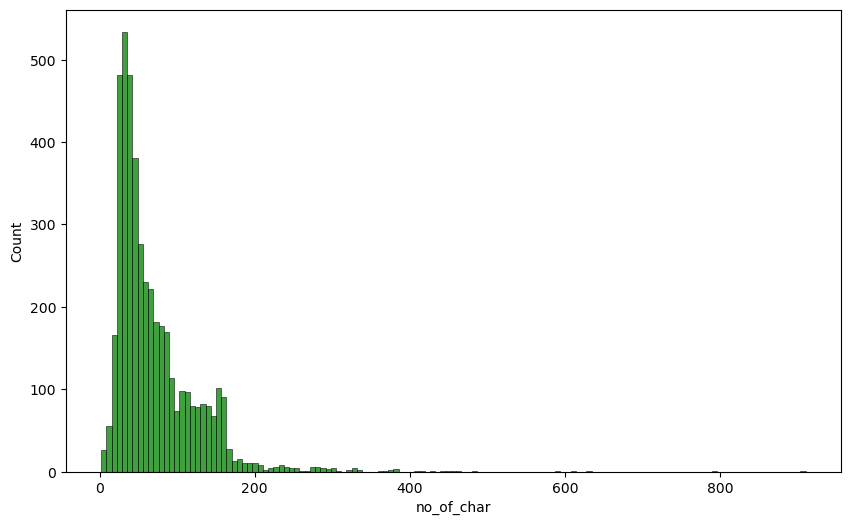

In [28]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['target']==0]['no_of_char'], color = 'green')

In [29]:
df[df['target'] == 1][['no_of_char', 'no_of_words', 'no_of_sentences']].describe()

,no_of_char,no_of_words,no_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='no_of_char', ylabel='Count'>

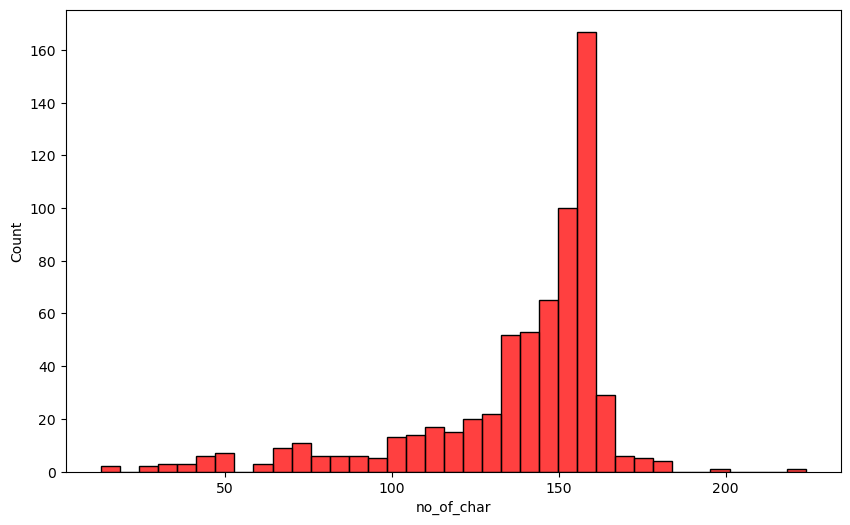

In [30]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['target']==1]['no_of_char'], color = 'red')

<Axes: xlabel='no_of_char', ylabel='Count'>

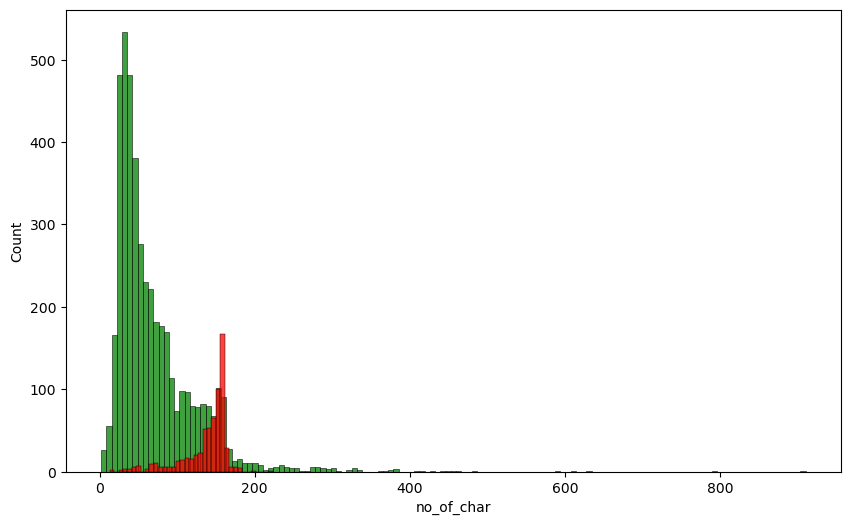

In [31]:
# compare both together
plt.figure(figsize = (10,6))
sns.histplot(df[df['target']==0]['no_of_char'], color = 'green')
sns.histplot(df[df['target']==1]['no_of_char'], color = 'red')

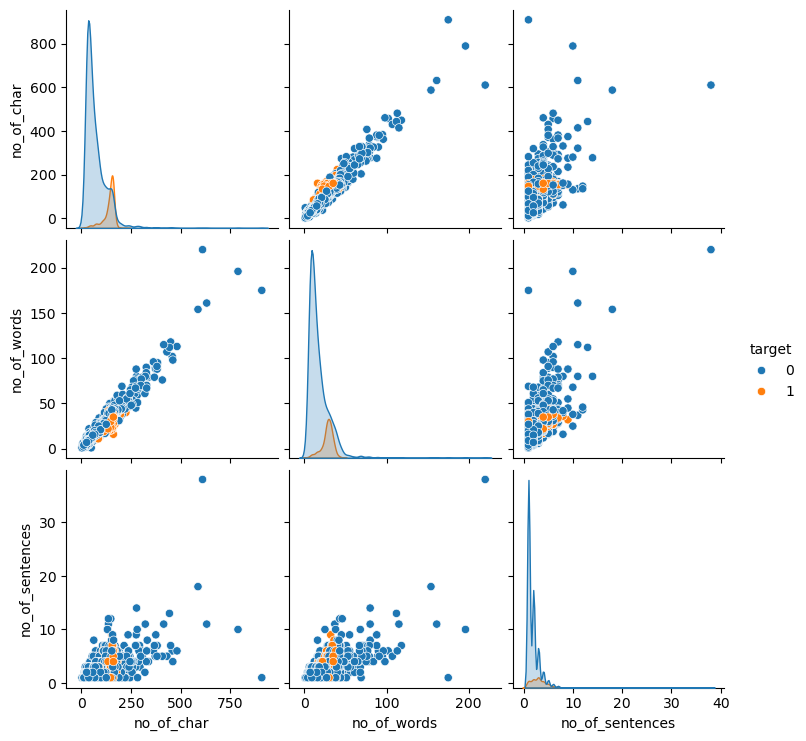

In [32]:
sns.pairplot(df, hue= 'target')
plt.show()

In [33]:
df.corr(numeric_only=True)

,target,no_of_char,no_of_words,no_of_sentences
target,1.000000,0.384717,0.262912,0.263939
no_of_char,0.384717,1.000000,0.965760,0.624139
no_of_words,0.262912,0.965760,1.000000,0.679971
no_of_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

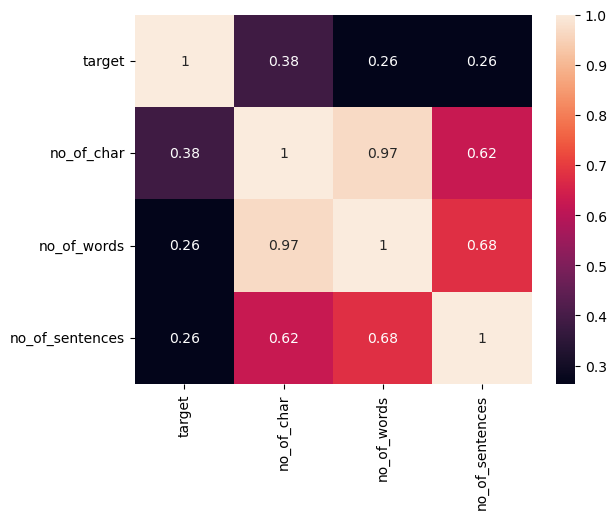

In [34]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [35]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [36]:
def preprocess_text (text) :
    text = text.lower()
    text = nltk.word_tokenize(text)
    k = []

    for i in text:
        if i.isalnum():
            k.append(i)
    text = k[:]
    k.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            k.append(i)
    text = k[:]
    k.clear()

    for i in text:
        k.append(ps.stem(i))
    return " ".join(k)

In [37]:
preprocess_text('hi my name is Anjali and Im 19 years old rn.')

'hi name anjali im 19 year old rn'

In [40]:
df['processed_text'] = df['sms'].apply(preprocess_text)

In [41]:
df.head()

,target,sms,no_of_char,no_of_words,no_of_sentences,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [42]:
l = []
for text in df[df['target']== 1]['processed_text'].tolist():
    for word in text.split():
        l.append(word)

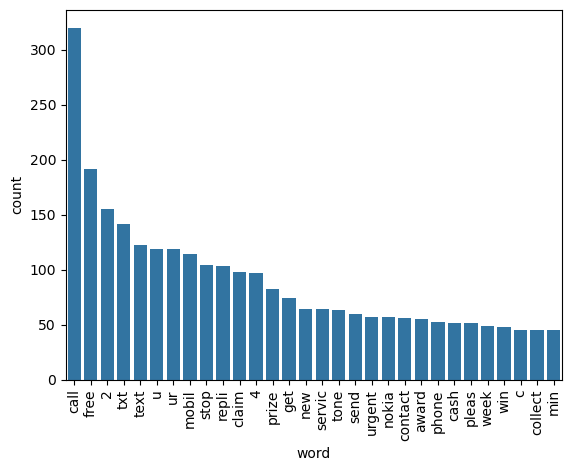

In [43]:
from collections import Counter
sns.barplot(x='word', y = 'count', data =pd.DataFrame(Counter(l).most_common(30), columns=['word', 'count']))
plt.xticks(rotation =90)
plt.show()

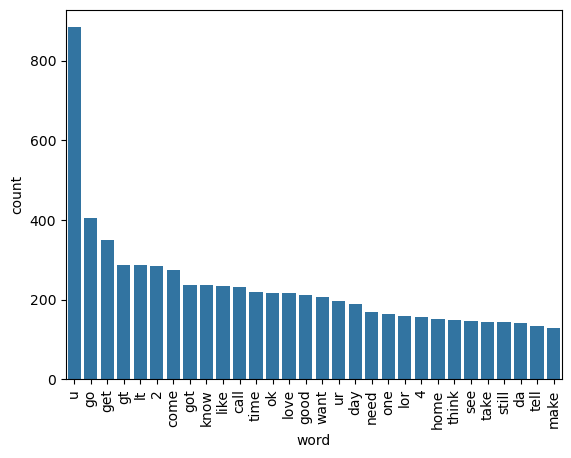

In [44]:
m = []
for text in df[df['target']== 0]['processed_text'].tolist():
    for word in text.split():
        m.append(word)

sns.barplot(x='word', y = 'count', data =pd.DataFrame(Counter(m).most_common(30), columns=['word', 'count']))
plt.xticks(rotation =90)
plt.show()

In [116]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
#cv = CountVectorizer()
#tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)

In [117]:
#x = cv.fit_transform(df['processed_text']).toarray()
x = tfidf.fit_transform(df['processed_text']).toarray()

In [94]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# x= scaler.fit_transform(x)

In [118]:
x.shape

(5169, 3000)

In [64]:
y = df['target'].values

In [65]:
from sklearn.model_selection import train_test_split

In [119]:
x_train, x_test, y_train, y_test = train_test_split (x,y,test_size=0.2,random_state=2)

In [67]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [68]:
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()

clfs = [gnb , mnb, bnb]

In [69]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

In [86]:
def training_func (clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    return {
        'Classifier': clf.__class__.__name__, 
        'Accuracy': accuracy_score(y_test, y_pred), 
        'Precision': precision_score(y_test, y_pred)
    }

In [58]:
results =[]
for clf in clfs :
    results.append(training_func(clf, x_train, y_train, x_test, y_test))

In [60]:
df_results_cv = pd.DataFrame(results)
print(df_results_cv)

      Classifier  Accuracy  Precision
0     GaussianNB  0.880077   0.531532
1  MultinomialNB  0.964217   0.834437
2    BernoulliNB  0.970019   0.973451


In [58]:
# TFIDF works better than the bag of words technique with CV

[(GaussianNB(), 0.8762088974854932, 0.5231481481481481), (MultinomialNB(), 0.9593810444874274, 1.0), (BernoulliNB(), 0.9700193423597679, 0.9734513274336283)]
        Classifier  Accuracy  Precision
0     GaussianNB()  0.876209   0.523148
1  MultinomialNB()  0.959381   1.000000
2    BernoulliNB()  0.970019   0.973451


In [71]:
results =[]
for clf in clfs :
    results.append(training_func(clf, x_train, y_train, x_test, y_test))

In [72]:
df_results_tfidf = pd.DataFrame(results)
print(df_results_tfidf)

      Classifier  Accuracy  Precision
0     GaussianNB  0.876209   0.523148
1  MultinomialNB  0.959381   1.000000
2    BernoulliNB  0.970019   0.973451


In [64]:
# due to data imbalance, we rely more on precision rather than accuracy
# so our best algorithm as for now is MultinomialNB (with TFIDF vectorization)

In [73]:
df_compare = df_results_cv.merge(df_results_tfidf, on='Classifier', suffixes=('_cv', '_tfidf'))
print(df_compare)

      Classifier  Accuracy_cv  Precision_cv  Accuracy_tfidf  Precision_tfidf
0     GaussianNB     0.880077      0.531532        0.876209         0.523148
1  MultinomialNB     0.964217      0.834437        0.959381         1.000000
2    BernoulliNB     0.970019      0.973451        0.970019         0.973451


## MultinomialNB (with TFIDF vectorization) is the better option within the above algorithms.

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
! pip install xgboost
from xgboost import XGBClassifier

In [75]:
lrc = LogisticRegression(solver = 'liblinear', penalty= 'l1')
svc = SVC (kernel = 'sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth = 5)
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbc = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [76]:
clfs2 = [mnb, lrc, svc, knc, dtc, rfc, abc, etc, gbc, xgb]

In [79]:
results = []
for clf in clfs2:
    print(f"Training and predicting with: {clf.__class__.__name__}")
    results.append(training_func(clf,x_train,y_train,x_test, y_test))
    

Training and predicting with: MultinomialNB
Training and predicting with: LogisticRegression
Training and predicting with: SVC
Training and predicting with: KNeighborsClassifier
Training and predicting with: DecisionTreeClassifier
Training and predicting with: RandomForestClassifier
Training and predicting with: AdaBoostClassifier
Training and predicting with: ExtraTreesClassifier
Training and predicting with: GradientBoostingClassifier
Training and predicting with: XGBClassifier


In [80]:
df_results_improv= pd.DataFrame(results)
print(df_results_improv)

                   Classifier  Accuracy  Precision
0               MultinomialNB  0.959381   1.000000
1          LogisticRegression  0.951644   0.940000
2                         SVC  0.972921   0.974138
3        KNeighborsClassifier  0.900387   1.000000
4      DecisionTreeClassifier  0.938104   0.862745
5      RandomForestClassifier  0.971954   1.000000
6          AdaBoostClassifier  0.924565   0.840909
7        ExtraTreesClassifier  0.972921   0.982456
8  GradientBoostingClassifier  0.952611   0.923810
9               XGBClassifier  0.970986   0.942623


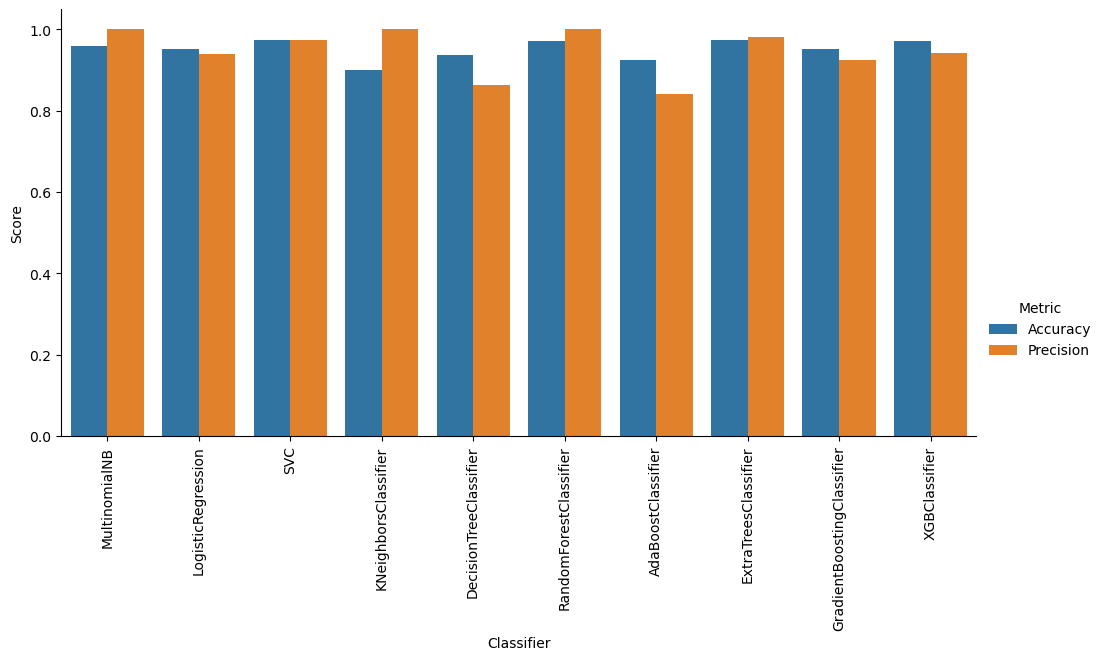

In [81]:
# 1. This line takes your data and makes it "thin and tall" so the chart can read it
plot_data = df_results_improv.melt(id_vars='Classifier', var_name='Metric', value_name='Score')

# 2. Now use 'plot_data' for your chart
sns.catplot(x='Classifier', y='Score', hue='Metric', data=plot_data, kind='bar', height=5, aspect=2)
plt.xticks(rotation=90)
plt.show()

In [88]:
results= []
for clf in clfs2:
    results.append(training_func(clf, x_train, y_train, x_test, y_test))

df_temp = pd.DataFrame(results)
print(df_temp)

                   Classifier  Accuracy  Precision
0               MultinomialNB  0.970986   1.000000
1          LogisticRegression  0.958414   0.970297
2                         SVC  0.975822   0.974790
3        KNeighborsClassifier  0.905222   1.000000
4      DecisionTreeClassifier  0.932302   0.833333
5      RandomForestClassifier  0.975822   0.982906
6          AdaBoostClassifier  0.924565   0.848837
7        ExtraTreesClassifier  0.974855   0.974576
8  GradientBoostingClassifier  0.946809   0.919192
9               XGBClassifier  0.970019   0.949580


In [89]:
df_compare_2 = df_results_improv.merge(df_temp, on='Classifier', suffixes = ['','_ft_3000'])
print(df_compare_2)

                   Classifier  Accuracy  Precision  Accuracy_ft_3000  \
0               MultinomialNB  0.959381   1.000000          0.970986   
1          LogisticRegression  0.951644   0.940000          0.958414   
2                         SVC  0.972921   0.974138          0.975822   
3        KNeighborsClassifier  0.900387   1.000000          0.905222   
4      DecisionTreeClassifier  0.938104   0.862745          0.932302   
5      RandomForestClassifier  0.971954   1.000000          0.975822   
6          AdaBoostClassifier  0.924565   0.840909          0.924565   
7        ExtraTreesClassifier  0.972921   0.982456          0.974855   
8  GradientBoostingClassifier  0.952611   0.923810          0.946809   
9               XGBClassifier  0.970986   0.942623          0.970019   

   Precision_ft_3000  
0           1.000000  
1           0.970297  
2           0.974790  
3           1.000000  
4           0.833333  
5           0.982906  
6           0.848837  
7           0.974576  


In [91]:
df_compare_2.sort_values(by=['Precision_ft_3000', 'Accuracy_ft_3000','Precision', 'Accuracy' ], ascending=[False, False, False, False])

,Classifier,Accuracy,Precision,Accuracy_ft_3000,Precision_ft_3000
0,MultinomialNB,0.959381,1.000000,0.970986,1.000000
3,KNeighborsClassifier,0.900387,1.000000,0.905222,1.000000
5,RandomForestClassifier,0.971954,1.000000,0.975822,0.982906
2,SVC,0.972921,0.974138,0.975822,0.974790
7,ExtraTreesClassifier,0.972921,0.982456,0.974855,0.974576
1,LogisticRegression,0.951644,0.940000,0.958414,0.970297
9,XGBClassifier,0.970986,0.942623,0.970019,0.949580
8,GradientBoostingClassifier,0.952611,0.923810,0.946809,0.919192
6,AdaBoostClassifier,0.924565,0.840909,0.924565,0.848837
4,DecisionTreeClassifier,0.938104,0.862745,0.932302,0.833333


In [96]:
results= []
for clf in clfs2:
    results.append(training_func(clf, x_train, y_train, x_test, y_test))

df_temp2 = pd.DataFrame(results)
print(df_temp2)

                   Classifier  Accuracy  Precision
0               MultinomialNB  0.978723   0.946154
1          LogisticRegression  0.967118   0.964286
2                         SVC  0.969052   0.927419
3        KNeighborsClassifier  0.905222   0.976190
4      DecisionTreeClassifier  0.931335   0.825243
5      RandomForestClassifier  0.975822   0.982906
6          AdaBoostClassifier  0.924565   0.848837
7        ExtraTreesClassifier  0.974855   0.974576
8  GradientBoostingClassifier  0.946809   0.919192
9               XGBClassifier  0.970019   0.949580


In [99]:
df_compare_3 = df_compare_2.merge(df_temp2, on='Classifier', suffixes = ['','_scaled'])
print(df_compare_3)

                   Classifier  Accuracy  Precision  Accuracy_ft_3000  \
0               MultinomialNB  0.959381   1.000000          0.970986   
1          LogisticRegression  0.951644   0.940000          0.958414   
2                         SVC  0.972921   0.974138          0.975822   
3        KNeighborsClassifier  0.900387   1.000000          0.905222   
4      DecisionTreeClassifier  0.938104   0.862745          0.932302   
5      RandomForestClassifier  0.971954   1.000000          0.975822   
6          AdaBoostClassifier  0.924565   0.840909          0.924565   
7        ExtraTreesClassifier  0.972921   0.982456          0.974855   
8  GradientBoostingClassifier  0.952611   0.923810          0.946809   
9               XGBClassifier  0.970986   0.942623          0.970019   

   Precision_ft_3000  Accuracy_scaled  Precision_scaled  
0           1.000000         0.978723          0.946154  
1           0.970297         0.967118          0.964286  
2           0.974790         0.96

In [101]:
df_compare_3.sort_values(by = ['Precision'], ascending = [False])

,Classifier,Accuracy,Precision,Accuracy_ft_3000,Precision_ft_3000,Accuracy_scaled,Precision_scaled
0,MultinomialNB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154
3,KNeighborsClassifier,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190
5,RandomForestClassifier,0.971954,1.000000,0.975822,0.982906,0.975822,0.982906
7,ExtraTreesClassifier,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576
2,SVC,0.972921,0.974138,0.975822,0.974790,0.969052,0.927419
9,XGBClassifier,0.970986,0.942623,0.970019,0.949580,0.970019,0.949580
1,LogisticRegression,0.951644,0.940000,0.958414,0.970297,0.967118,0.964286
8,GradientBoostingClassifier,0.952611,0.923810,0.946809,0.919192,0.946809,0.919192
4,DecisionTreeClassifier,0.938104,0.862745,0.932302,0.833333,0.931335,0.825243
6,AdaBoostClassifier,0.924565,0.840909,0.924565,0.848837,0.924565,0.848837


In [127]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(estimators=[
    ('mnb', mnb), 
    ('rfc', rfc), 
    ('svc', svc),
    ('etc', etc)
], voting='hard')

# Train it like any other model
voting_hard.fit(x_train, y_train)
y_pred_voting = voting_hard.predict(x_test)

print("Voting Accuracy:", accuracy_score(y_test, y_pred_voting))
print("Voting precision:", precision_score(y_test, y_pred_voting))

Voting Accuracy: 0.97678916827853
Voting precision: 1.0


In [128]:
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)

voting_soft = VotingClassifier(estimators=[
    ('mnb', mnb), 
    ('rfc', rfc), 
    ('svc', svc), 
    ('etc', etc)
], voting='soft') 

voting_soft.fit(x_train, y_train)
y_pred_voting = voting_soft.predict(x_test)

print("Voting Accuracy:", accuracy_score(y_test, y_pred_voting))
print("Voting Precision:", precision_score(y_test, y_pred_voting))

Voting Accuracy: 0.9796905222437138
Voting Precision: 0.9915966386554622


In [124]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('mnb', mnb), 
    ('rfc', rfc), 
    ('svc', svc),
    ('etc', etc)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

stacking.fit(x_train, y_train)
y_pred_stacking = stacking.predict(x_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stacking))

Stacking Accuracy: 0.9816247582205029


In [125]:
print("Stacking Precision:", precision_score(y_test, y_pred_stacking))

Stacking Precision: 0.968503937007874


In [129]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(voting_hard, open('model.pkl', 'wb'))